In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import os

# Load CSV files with correct paths
train_df = pd.read_csv("/kaggle/input/ai-vs-human-generated-dataset/train.csv")
test_df = pd.read_csv("/kaggle/input/ai-vs-human-generated-dataset/test.csv")

# Display basic info
print(train_df.head())
print(train_df.info())

# Check class distribution
print(train_df['label'].value_counts())

# Define the correct image folder paths
TRAIN_IMAGES_PATH = "/kaggle/input/ai-vs-human-generated-dataset/"
TEST_IMAGES_PATH = "/kaggle/input/ai-vs-human-generated-dataset/"

   Unnamed: 0                                        file_name  label
0           0  train_data/a6dcb93f596a43249135678dfcfc17ea.jpg      1
1           1  train_data/041be3153810433ab146bc97d5af505c.jpg      0
2           2  train_data/615df26ce9494e5db2f70e57ce7a3a4f.jpg      1
3           3  train_data/8542fe161d9147be8e835e50c0de39cd.jpg      0
4           4  train_data/5d81fa12bc3b4cea8c94a6700a477cf2.jpg      1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79950 entries, 0 to 79949
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  79950 non-null  int64 
 1   file_name   79950 non-null  object
 2   label       79950 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 1.8+ MB
None
label
1    39975
0    39975
Name: count, dtype: int64


#  Image Samples (Preview)

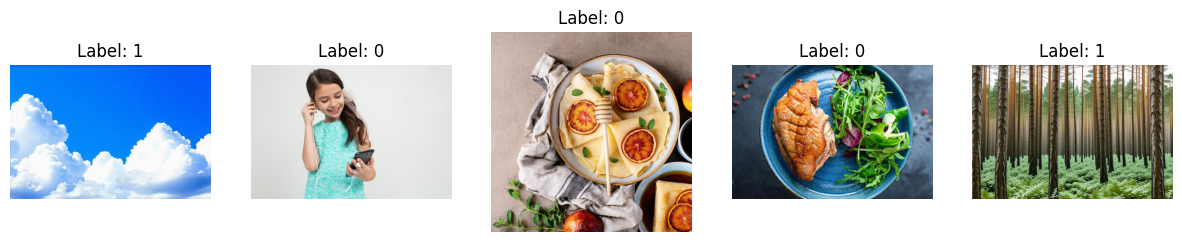

In [2]:
# Load and display a few sample images
def show_sample_images(df, image_folder, num_samples=5):
    sample_images = df.sample(num_samples, random_state=42)

    fig, axes = plt.subplots(1, num_samples, figsize=(15, 5))
    for i, (_, row) in enumerate(sample_images.iterrows()):
        img_path = os.path.join(image_folder, row["file_name"])  # Use file_name directly

        if os.path.exists(img_path):  # Check if file exists
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
            axes[i].imshow(img)
            axes[i].set_title(f"Label: {row['label']}")
            axes[i].axis("off")
        else:
            print(f" File not found: {img_path}")

    plt.show()

# Show sample images from the training dataset
show_sample_images(train_df, TRAIN_IMAGES_PATH)

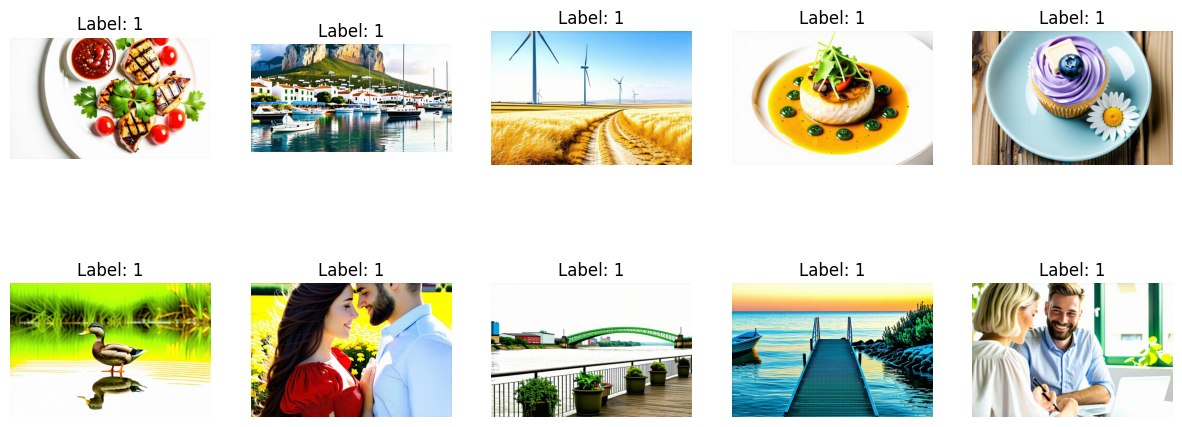

In [3]:
def show_ai_generated_images(df, base_path, num_samples=10):
    """Displays a sample of AI-generated images (label = 1)"""
    ai_images = df[df["label"] == 1].sample(num_samples, random_state=42)

    fig, axes = plt.subplots(2, 5, figsize=(15, 6))  # 2 rows, 5 columns
    axes = axes.ravel()  # Flatten to 1D array for easy iteration

    for i, (_, row) in enumerate(ai_images.iterrows()):
        img_path = os.path.join(base_path, row["file_name"])  # Use correct file path

        if os.path.exists(img_path):  # Ensure file exists
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
            axes[i].imshow(img)
            axes[i].set_title(f"Label: {row['label']}")
            axes[i].axis("off")
        else:
            print(f" File not found: {img_path}")

    plt.show()

# Call function to show 10 AI-generated images
show_ai_generated_images(train_df, TRAIN_IMAGES_PATH)

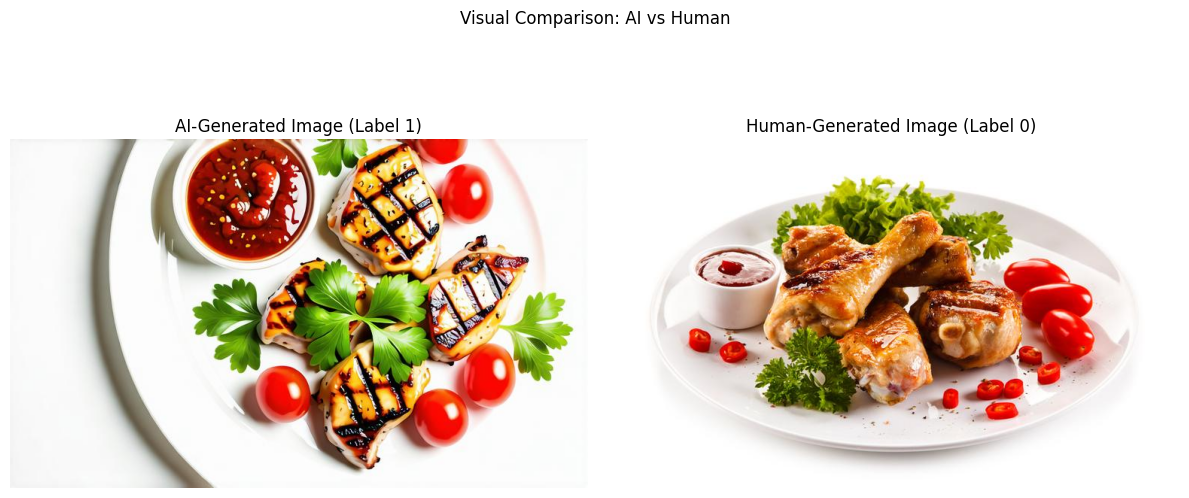

In [4]:
# === SECTION: AI vs Human Image Comparison ===

# Select one image from each class
ai_image_name = train_df[train_df["label"] == 1].sample(1, random_state=42)["file_name"].values[0]
human_image_name = train_df[train_df["label"] == 0].sample(1, random_state=42)["file_name"].values[0]

# Construct full paths using TRAIN_IMAGES_PATH
ai_image_path = os.path.join(TRAIN_IMAGES_PATH, ai_image_name)
human_image_path = os.path.join(TRAIN_IMAGES_PATH, human_image_name)

# Load images
ai_image = cv2.imread(ai_image_path)
human_image = cv2.imread(human_image_path)

# Validate loading
if ai_image is None or human_image is None:
    raise FileNotFoundError("One or both images could not be loaded.")

# Convert BGR to RGB for display
ai_image = cv2.cvtColor(ai_image, cv2.COLOR_BGR2RGB)
human_image = cv2.cvtColor(human_image, cv2.COLOR_BGR2RGB)

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(ai_image)
axes[0].set_title("AI-Generated Image (Label 1)")
axes[0].axis("off")

axes[1].imshow(human_image)
axes[1].set_title("Human-Generated Image (Label 0)")
axes[1].axis("off")

plt.suptitle("Visual Comparison: AI vs Human")
plt.tight_layout()
plt.show()


# Image Size and Aspect Ratio


Reading image sizes: 100%|██████████| 79950/79950 [17:18<00:00, 77.01it/s]


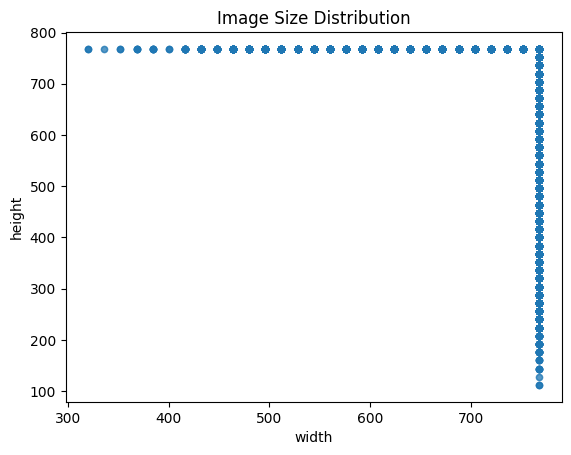

In [5]:
from tqdm import tqdm  # Progress bar
import cv2
import os
import pandas as pd
import matplotlib.pyplot as plt

image_shapes = []

# Faster loop with minimal decoding (no color conversion needed)
for fname in tqdm(train_df['file_name'], desc="Reading image sizes"):
    img_path = os.path.join(TRAIN_IMAGES_PATH, fname)
    if os.path.exists(img_path):
        img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)  # Faster than full decode
        if img is not None:
            h, w = img.shape[:2]
            image_shapes.append((w, h))

# Convert to DataFrame and plot
shapes_df = pd.DataFrame(image_shapes, columns=['width', 'height'])
shapes_df.plot.scatter(x='width', y='height', alpha=0.5)
plt.title("Image Size Distribution")
plt.show()


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


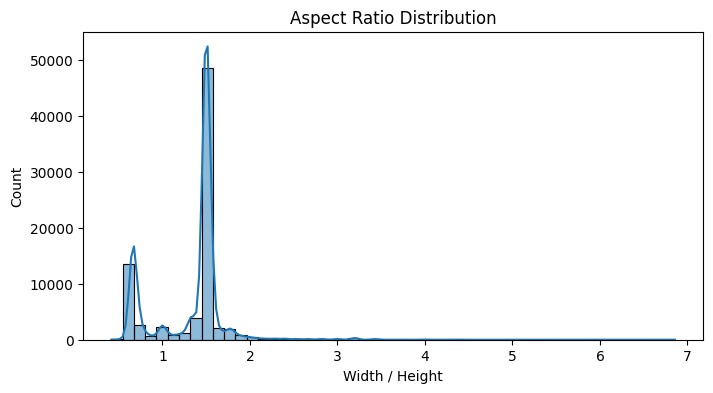

In [6]:
import seaborn as sns
shapes_df['aspect_ratio'] = shapes_df['width'] / shapes_df['height']
plt.figure(figsize=(8, 4))
sns.histplot(shapes_df['aspect_ratio'], bins=50, kde=True)
plt.title("Aspect Ratio Distribution")
plt.xlabel("Width / Height")
plt.show()

Reading test image sizes: 100%|██████████| 5540/5540 [03:46<00:00, 24.47it/s]


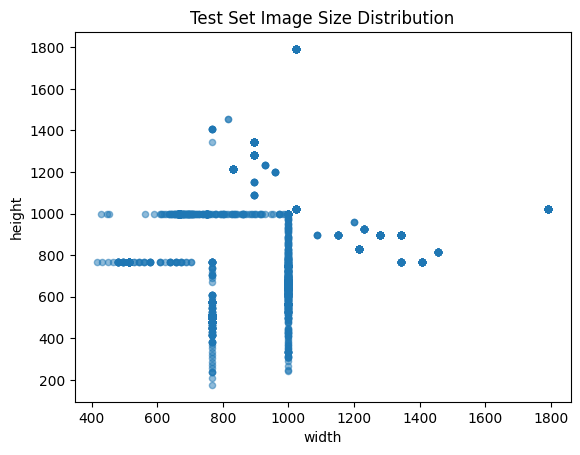

In [7]:
test_image_shapes = []

# Loop over test set filenames
for fname in tqdm(test_df['id'], desc="Reading test image sizes"):
    img_path = os.path.join(TEST_IMAGES_PATH, fname)
    if os.path.exists(img_path):
        img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
        if img is not None:
            h, w = img.shape[:2]
            test_image_shapes.append((w, h))

# Convert to DataFrame and plot
test_shapes_df = pd.DataFrame(test_image_shapes, columns=['width', 'height'])
test_shapes_df.plot.scatter(x='width', y='height', alpha=0.5)
plt.title("Test Set Image Size Distribution")
plt.xlabel("width")
plt.ylabel("height")
plt.show()

### Test set has larger resolution diversity, which may hurt model generalization if not handled.

# Brightness and Contrast

In [8]:
def compute_brightness_column(df, image_path, reduced=False):
    """
    Computes mean brightness for images listed in a DataFrame.

    Parameters:
    - df: DataFrame containing 'file_name' column
    - image_path: Directory where images are stored
    - reduced: If True, use reduced-resolution grayscale loading

    Returns:
    - brightness_values: List of brightness means
    """
    brightness_values = []

    flag = cv2.IMREAD_REDUCED_GRAYSCALE_2 if reduced else cv2.IMREAD_GRAYSCALE

    for fname in tqdm(df['file_name'], desc="Computing brightness"):
        path = os.path.join(image_path, fname)
        img = cv2.imread(path, flag)
        if img is not None:
            brightness_values.append(img.mean())
        else:
            brightness_values.append(None)

    return brightness_values

train_df['brightness'] = compute_brightness_column(train_df, TRAIN_IMAGES_PATH)

Computing brightness: 100%|██████████| 79950/79950 [09:24<00:00, 141.71it/s]


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

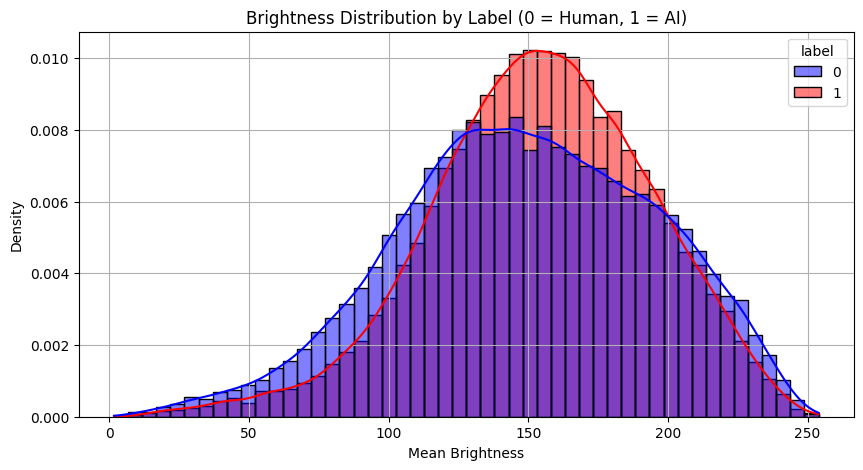

In [9]:
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(
    data=train_df,
    x='brightness',
    hue='label',
    bins=50,
    kde=True,
    palette={0: 'blue', 1: 'red'},
    stat='density',
    common_norm=False
)

plt.title("Brightness Distribution by Label (0 = Human, 1 = AI)")
plt.xlabel("Mean Brightness")
plt.ylabel("Density")
plt.grid(True)
plt.show()

# Entropy and Edge Complexity

In [10]:
from skimage.measure import shannon_entropy
from joblib import Parallel, delayed
from tqdm import tqdm

def calc_entropy(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    return shannon_entropy(img) if img is not None else None

def calc_edge_density(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is not None:
        edges = cv2.Canny(img, 100, 200)
        return edges.sum() / (img.shape[0] * img.shape[1])
    return None

def compute_feature_parallel(df, path, func, column_name, n_jobs=-1):
    print(f" Computing {column_name}...")
    img_paths = [os.path.join(path, f) for f in df['file_name']]
    results = Parallel(n_jobs=n_jobs)(
        delayed(func)(p) for p in tqdm(img_paths)
    )
    df[column_name] = results

# === Apply to train_df ===
compute_feature_parallel(train_df, TRAIN_IMAGES_PATH, calc_entropy, 'entropy')
compute_feature_parallel(train_df, TRAIN_IMAGES_PATH, calc_edge_density, 'edge_density')


 Computing entropy...


100%|██████████| 79950/79950 [08:59<00:00, 148.12it/s]


 Computing edge_density...


100%|██████████| 79950/79950 [06:29<00:00, 205.44it/s]


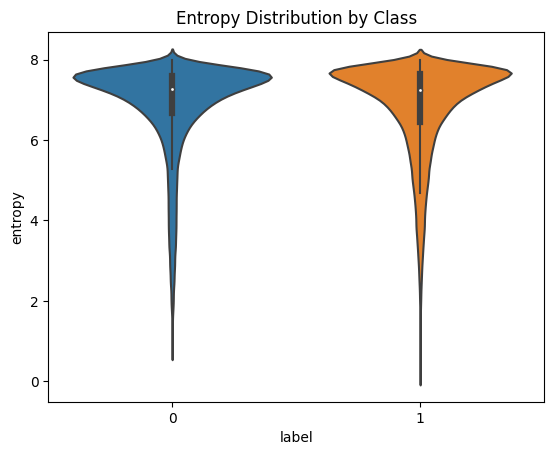

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


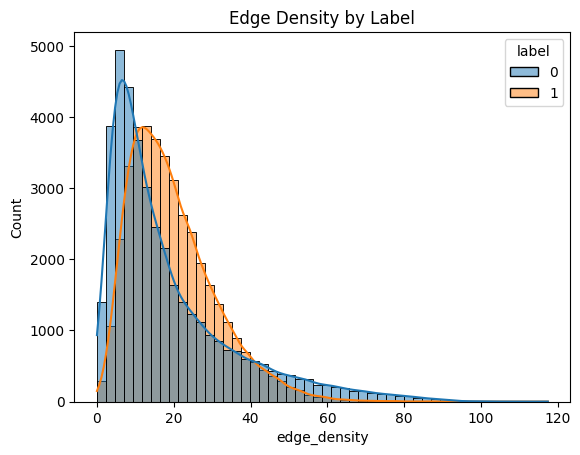

In [11]:
# Entropy distribution
sns.violinplot(x='label', y='entropy', data=train_df)
plt.title("Entropy Distribution by Class")
plt.show()

# Edge density histogram
sns.histplot(data=train_df, x='edge_density', hue='label', bins=50, kde=True)
plt.title("Edge Density by Label")
plt.show()


# RGB Color Histograms

In [12]:
# === SECTION: Color and Frequency Feature Analysis ===

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from joblib import Parallel, delayed
from skimage.measure import shannon_entropy


In [13]:
# === RGB Color Histogram Viewer ===
def plot_color_histograms(df, folder, num_samples=3):
    samples = df.sample(num_samples, random_state=42)
    for _, row in samples.iterrows():
        img = cv2.imread(os.path.join(folder, row["file_name"]))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(10, 4))
        plt.title(f"Color Histogram: {row['file_name']} | Label: {row['label']}")
        for i, color in enumerate(['r', 'g', 'b']):
            hist = cv2.calcHist([img], [i], None, [256], [0, 256])
            plt.plot(hist, color=color)
        plt.xlim([0, 256])
        plt.tight_layout()
        plt.show()

In [14]:
# === HSV Histogram Extraction and Feature Calculation ===
def extract_hsv_histograms(image_path, bins=32):
    image = cv2.imread(image_path)
    if image is None:
        return None, None, None
    image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    hist_hue = cv2.normalize(cv2.calcHist([image], [0], None, [bins], [0, 180]), None).flatten()
    hist_sat = cv2.normalize(cv2.calcHist([image], [1], None, [bins], [0, 256]), None).flatten()
    hist_val = cv2.normalize(cv2.calcHist([image], [2], None, [bins], [0, 256]), None).flatten()
    return hist_hue, hist_sat, hist_val

def batch_hsv_histograms(image_list, path, n_jobs=-1):
    return Parallel(n_jobs=n_jobs)(
        delayed(extract_hsv_histograms)(os.path.join(path, fname)) for fname in tqdm(image_list)
    )


In [15]:
# Sample 1000 AI and Human images
ai_images = train_df[train_df["label"] == 1].sample(1000, random_state=42)["file_name"].values
human_images = train_df[train_df["label"] == 0].sample(1000, random_state=42)["file_name"].values

ai_hsv_histograms = batch_hsv_histograms(ai_images, TRAIN_IMAGES_PATH)
human_hsv_histograms = batch_hsv_histograms(human_images, TRAIN_IMAGES_PATH)

# Filter per-channel histograms
ai_hue_histograms = [h[0] for h in ai_hsv_histograms if h[0] is not None]
ai_sat_histograms = [h[1] for h in ai_hsv_histograms if h[1] is not None]
ai_val_histograms = [h[2] for h in ai_hsv_histograms if h[2] is not None]

human_hue_histograms = [h[0] for h in human_hsv_histograms if h[0] is not None]
human_sat_histograms = [h[1] for h in human_hsv_histograms if h[1] is not None]
human_val_histograms = [h[2] for h in human_hsv_histograms if h[2] is not None]

100%|██████████| 1000/1000 [00:03<00:00, 298.96it/s]


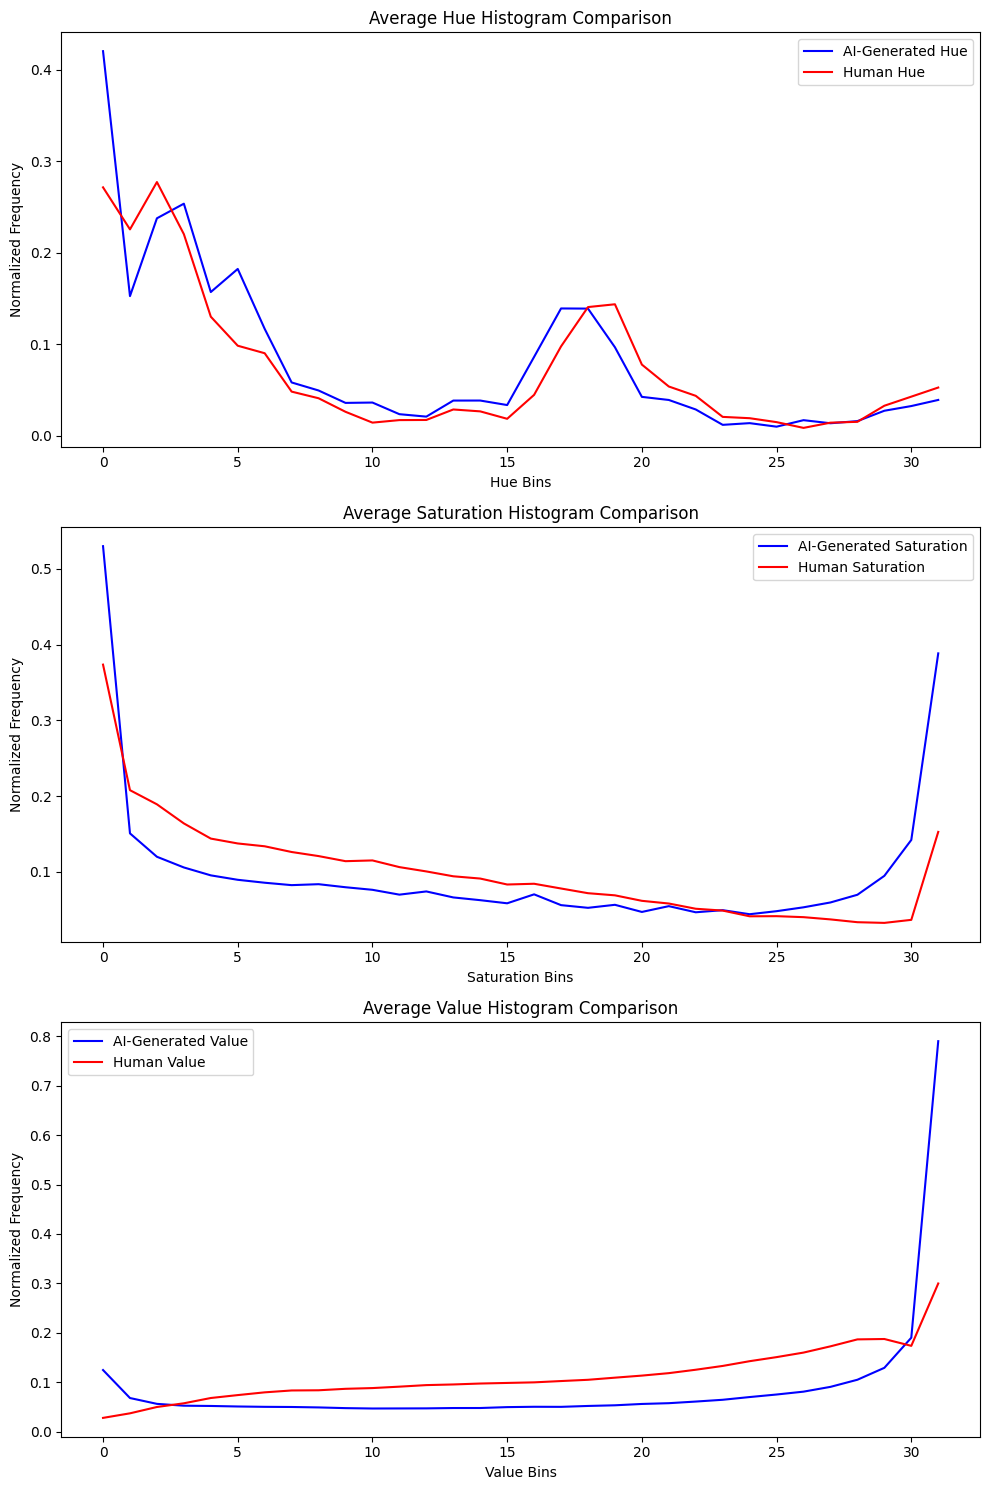

In [16]:
# Compute average histograms
avg_ai_hue = np.mean(ai_hue_histograms, axis=0)
avg_ai_sat = np.mean(ai_sat_histograms, axis=0)
avg_ai_val = np.mean(ai_val_histograms, axis=0)

avg_human_hue = np.mean(human_hue_histograms, axis=0)
avg_human_sat = np.mean(human_sat_histograms, axis=0)
avg_human_val = np.mean(human_val_histograms, axis=0)

# Plot histograms
fig, axes = plt.subplots(3, 1, figsize=(10, 15))

axes[0].plot(avg_ai_hue, label="AI-Generated Hue", color='blue')
axes[0].plot(avg_human_hue, label="Human Hue", color='red')
axes[0].set_title("Average Hue Histogram Comparison")
axes[0].set_xlabel("Hue Bins")
axes[0].set_ylabel("Normalized Frequency")
axes[0].legend()

axes[1].plot(avg_ai_sat, label="AI-Generated Saturation", color='blue')
axes[1].plot(avg_human_sat, label="Human Saturation", color='red')
axes[1].set_title("Average Saturation Histogram Comparison")
axes[1].set_xlabel("Saturation Bins")
axes[1].set_ylabel("Normalized Frequency")
axes[1].legend()

axes[2].plot(avg_ai_val, label="AI-Generated Value", color='blue')
axes[2].plot(avg_human_val, label="Human Value", color='red')
axes[2].set_title("Average Value Histogram Comparison")
axes[2].set_xlabel("Value Bins")
axes[2].set_ylabel("Normalized Frequency")
axes[2].legend()

plt.tight_layout()
plt.show()

In [17]:
# Feature vector construction
def compute_features(hue, sat, val):
    return [
        np.mean(val, axis=0)[-1],
        np.var(val, axis=0)[-1],
        np.mean(sat, axis=0)[-1],
        np.var(sat, axis=0)[-1],
        *np.fft.fft(hue[0])[:1].real,
        *np.fft.fft(sat[-1])[-1:].real,
        *np.fft.fft(val[-1])[-1:].real
    ]

ai_features = np.array([compute_features(ai_hue_histograms, ai_sat_histograms, ai_val_histograms)])
human_features = np.array([compute_features(human_hue_histograms, human_sat_histograms, human_val_histograms)])

avg_ai_features = np.mean(ai_features, axis=0)
avg_human_features = np.mean(human_features, axis=0)


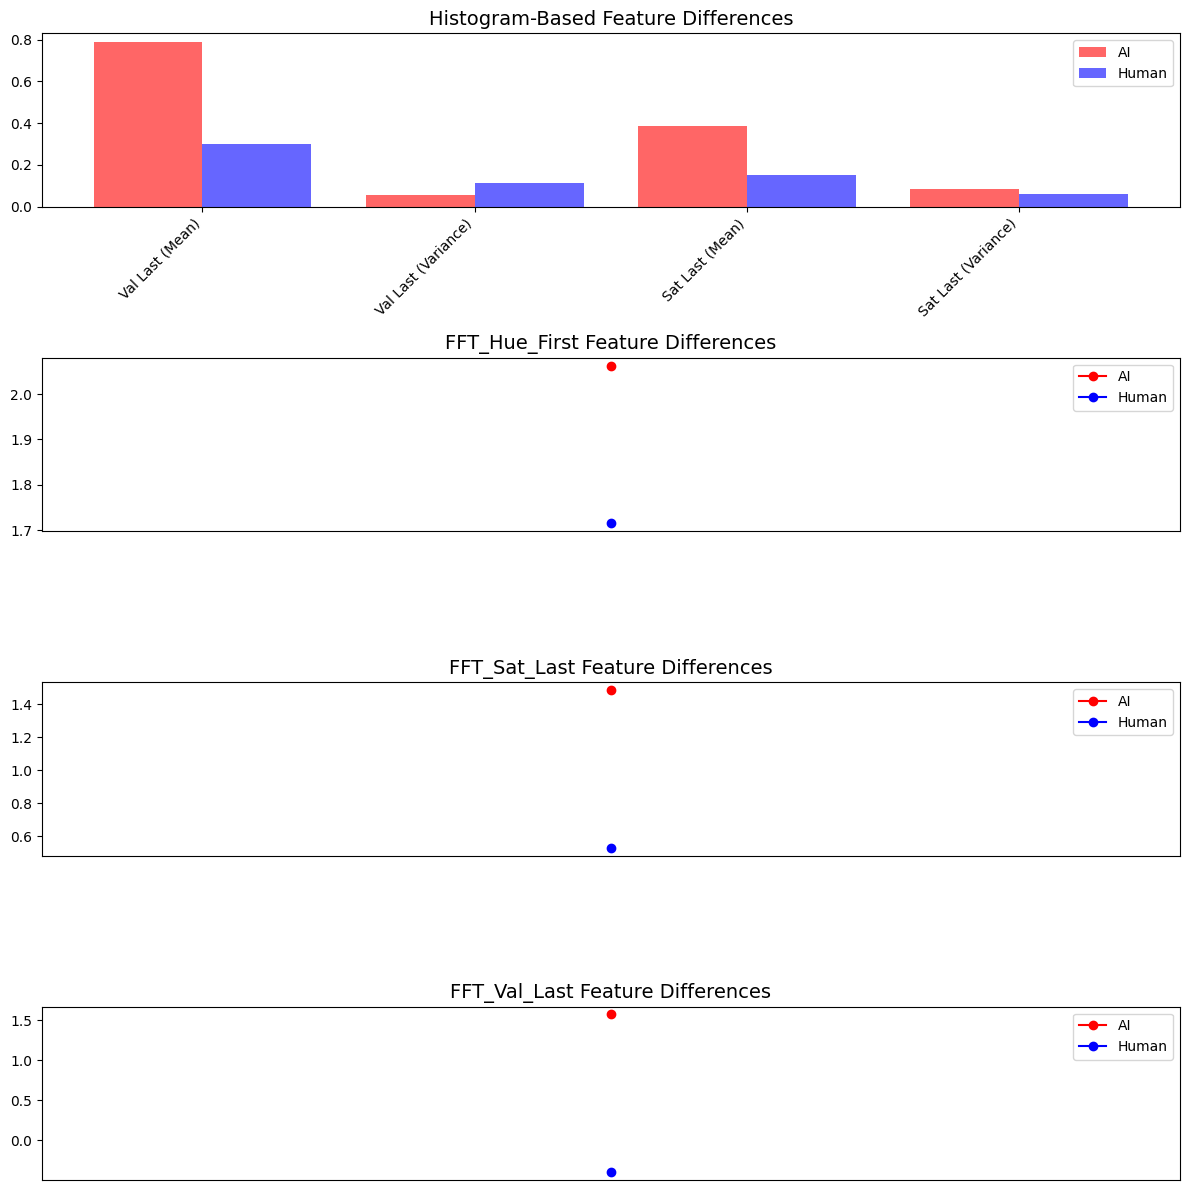

In [18]:
# Plot Feature Comparison
fig, axes = plt.subplots(4, 1, figsize=(12, 12))
hist_indices = [0, 1, 2, 3]
hist_labels = ["Val Last (Mean)", "Val Last (Variance)", "Sat Last (Mean)", "Sat Last (Variance)"]

x = np.arange(len(hist_labels))
width = 0.4

axes[0].bar(x - width/2, avg_ai_features[hist_indices], width, label="AI", color="red", alpha=0.6)
axes[0].bar(x + width/2, avg_human_features[hist_indices], width, label="Human", color="blue", alpha=0.6)
axes[0].set_xticks(x)
axes[0].set_xticklabels(hist_labels, rotation=45, ha="right")
axes[0].set_title("Histogram-Based Feature Differences", fontsize=14)
axes[0].legend()

fft_indices = [4, 5, 6]
fft_labels = ["FFT_Hue_First", "FFT_Sat_Last", "FFT_Val_Last"]

for i in range(3):
    axes[i+1].plot([0], [avg_ai_features[fft_indices[i]]], label="AI", color="red", marker='o', linestyle='-')
    axes[i+1].plot([0], [avg_human_features[fft_indices[i]]], label="Human", color="blue", marker='o', linestyle='-')
    axes[i+1].set_title(f"{fft_labels[i]} Feature Differences", fontsize=14)
    axes[i+1].set_xticks([])
    axes[i+1].legend()

plt.subplots_adjust(hspace=0.5)
plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


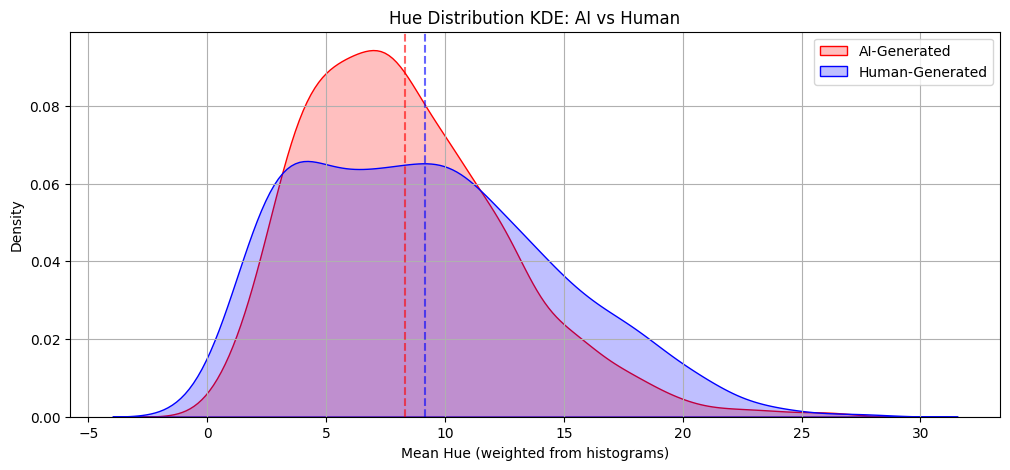

In [19]:

# === Step 1: Compute Mean Hue from Histograms ===
ai_mean_hues = [np.average(np.arange(len(h)), weights=h) for h in ai_hue_histograms]
human_mean_hues = [np.average(np.arange(len(h)), weights=h) for h in human_hue_histograms]

# === Step 2: Plot KDE ===
plt.figure(figsize=(12, 5))
sns.kdeplot(ai_mean_hues, label='AI-Generated', color='red', fill=True)
sns.kdeplot(human_mean_hues, label='Human-Generated', color='blue', fill=True)

# === Step 3: Add vertical mean lines ===
plt.axvline(np.mean(ai_mean_hues), color='red', linestyle='--', alpha=0.6)
plt.axvline(np.mean(human_mean_hues), color='blue', linestyle='--', alpha=0.6)

plt.xlabel('Mean Hue (weighted from histograms)')
plt.ylabel('Density')
plt.title('Hue Distribution KDE: AI vs Human')
plt.legend()
plt.grid(True)
plt.show()


# SNR

In [20]:
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from concurrent.futures import ThreadPoolExecutor, as_completed
from scipy.stats import skew, kurtosis
from numpy.fft import fft2

# ================
# === SNR Function ===
# ================
def calculate_snr(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    img = cv2.resize(img, (128, 128))  # Resize for speed
    signal = np.mean(img)
    noise = np.std(img)
    return float('inf') if noise == 0 else 20 * np.log10(signal / noise)

# ================
# === Feature Extraction Function ===
# ================
def extract_features_from_image(image_path):
    image = cv2.imread(image_path)
    if image is None:
        return None
    image = cv2.resize(image, (512, 512))
    features = []

    # SNR
    snr = calculate_snr(image_path)
    features.append(snr)

    # Mean / Std (avoid zero division)
    features.append(np.mean(image) / (np.std(image) + 1e-5))

    # Laplacian variance (focus measure)
    laplacian_var = cv2.Laplacian(cv2.cvtColor(image, cv2.COLOR_BGR2GRAY), cv2.CV_64F).var()
    features.append(laplacian_var)

    # Edge density
    edge_density = np.sum(cv2.Canny(image, 100, 200) > 0) / (512 * 512)
    features.append(edge_density)

    # RGB Skewness & Kurtosis
    for i in range(3):
        channel = image[:, :, i].flatten()
        features.append(skew(channel))
        features.append(kurtosis(channel))

    # HSV Variance
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    features.append(np.var(hsv[:, :, 1].flatten()))  # Saturation variance
    features.append(np.var(hsv[:, :, 0].flatten()))  # Hue variance

    # Frequency domain energy (high freq)
    f = np.abs(fft2(cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)))
    features.append(np.sum(f[30:, 30:]) / np.sum(f))

    return features

# ================
# === Parallel Feature Extraction ===
# ================
def build_features_dataframe_threadpool(image_folder, max_workers=8):
    image_names = os.listdir(image_folder)
    features_list = []

    def extract_single(img_name):
        return extract_features_from_image(os.path.join(image_folder, img_name))

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(extract_single, img_name) for img_name in tqdm(image_names, desc="Extracting", position=0, leave=True)]
        for img_name, future in zip(image_names, futures):
            result = future.result()
            if result is not None:
                features_list.append(result + [img_name])  # Append image name for later merge

    columns = ['SNR', 'MeanStdRatio', 'LaplacianVar', 'EdgeDensity',
               'BlueSkew', 'BlueKurtosis', 'GreenSkew', 'GreenKurtosis',
               'RedSkew', 'RedKurtosis', 'SatVariance', 'HueVariance', 'HighFreqEnergy', 'ImageName']
    df = pd.DataFrame(features_list, columns=columns)
    return df

# ================
# === Load Labels & Paths ===
# ================
train_labels = pd.read_csv('/kaggle/input/ai-vs-human-generated-dataset/train.csv')
test_labels = pd.read_csv('/kaggle/input/ai-vs-human-generated-dataset/test.csv')

train_labels['file_name'] = train_labels['file_name'].apply(lambda x: os.path.basename(x))
test_labels['id'] = test_labels['id'].apply(lambda x: os.path.basename(x))

train_images_path = '/kaggle/input/ai-vs-human-generated-dataset/train_data'
test_images_path = '/kaggle/input/ai-vs-human-generated-dataset/test_data_v2'

# ================
# === Feature Extraction ===
# ================
print("Extracting Train Features...")
train_features = build_features_dataframe_threadpool(train_images_path)

print("Extracting Test Features...")
test_features = build_features_dataframe_threadpool(test_images_path)

# ================
# === Merge Features with Labels ===
# ================
train_df = pd.merge(train_labels, train_features, left_on='file_name', right_on='ImageName')
test_df = pd.merge(test_labels, test_features, left_on='id', right_on='ImageName')
train_df.drop(columns=['ImageName'], inplace=True)
test_df.drop(columns=['ImageName'], inplace=True)



Extracting Train Features...


Extracting: 100%|██████████| 79950/79950 [00:02<00:00, 27830.27it/s]


Extracting Test Features...


Extracting: 100%|██████████| 5540/5540 [00:00<00:00, 27529.57it/s]


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

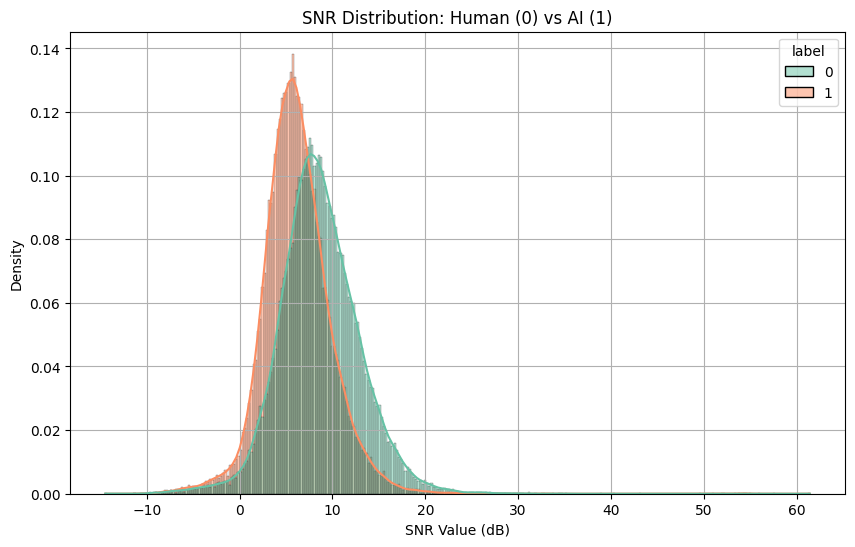

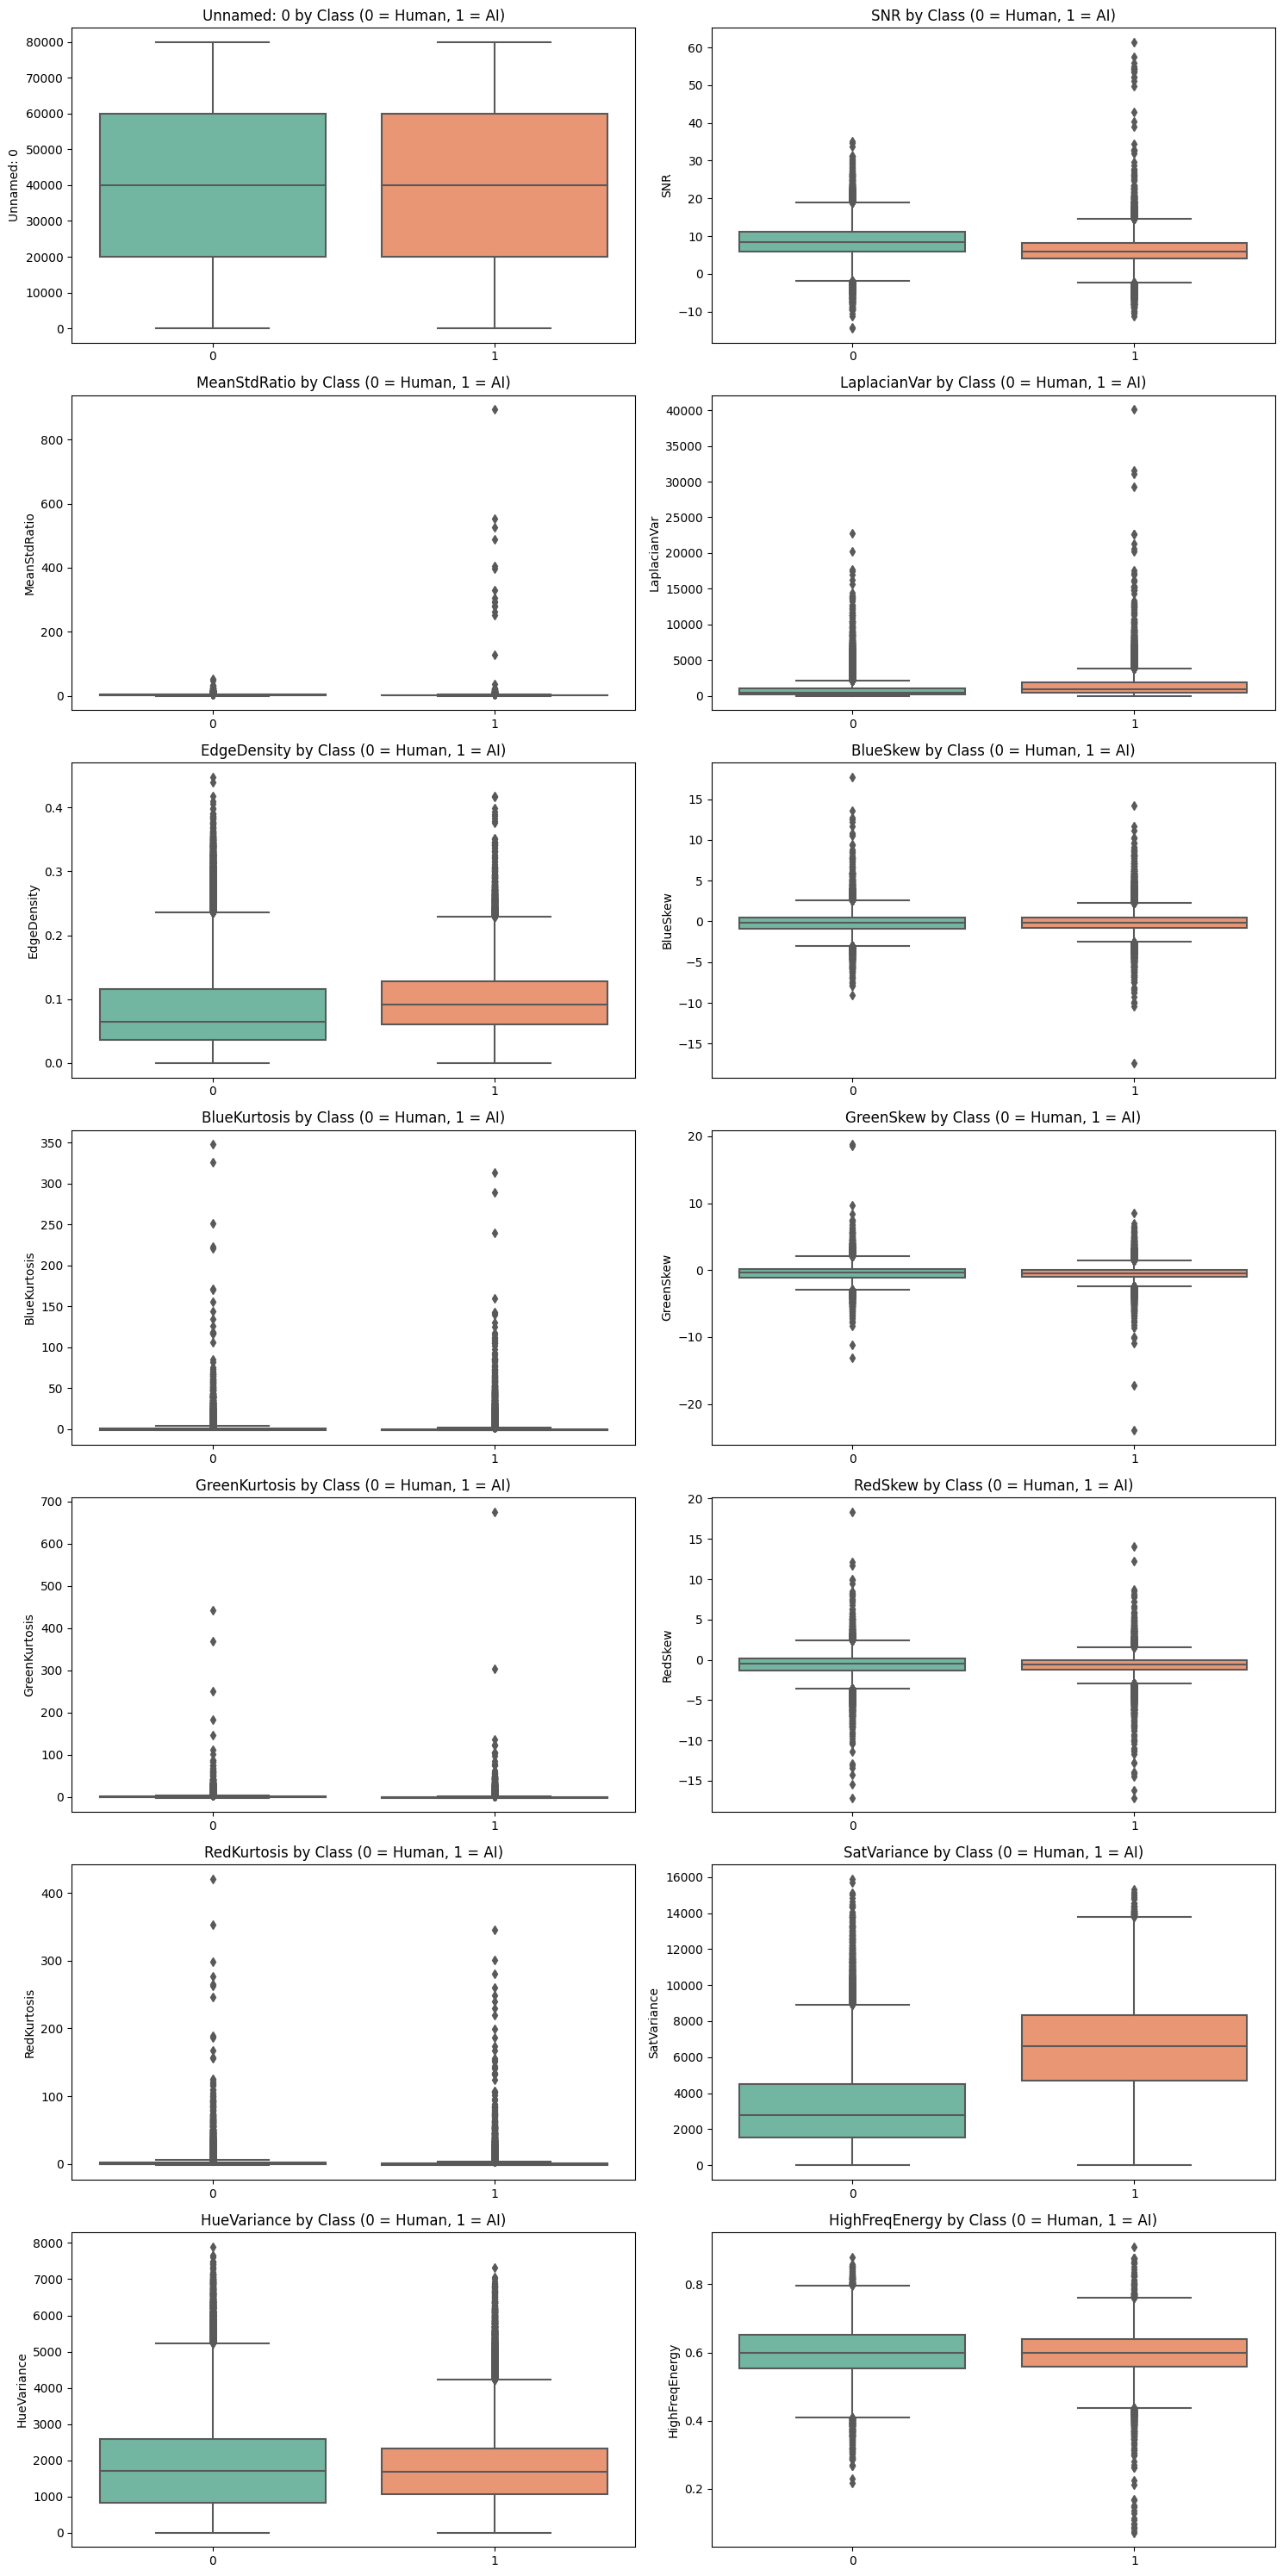

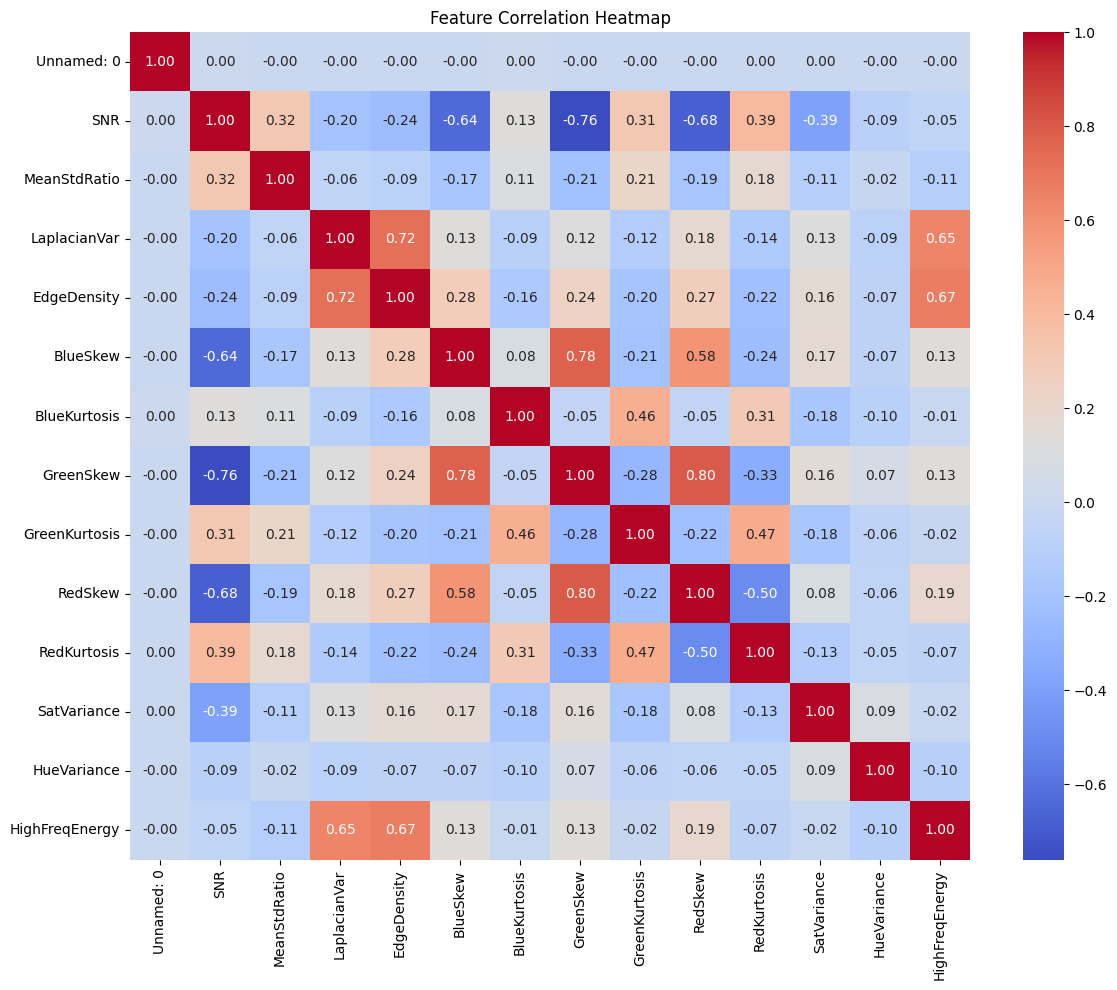

In [21]:

# ================
# === Plot SNR Distribution ===
# ================
plt.figure(figsize=(10, 6))
sns.histplot(
    data=train_df,
    x='SNR',
    hue='label',
    kde=True,
    stat='density',
    common_norm=False,
    palette='Set2'
)
plt.title('SNR Distribution: Human (0) vs AI (1)')
plt.xlabel('SNR Value (dB)')
plt.ylabel('Density')
plt.grid(True)
plt.show()

# ================
# === Boxplots for Features ===
# ================
plt.figure(figsize=(15, 30))
feature_cols = train_df.drop(columns=['file_name', 'label']).columns

for i, col in enumerate(feature_cols):
    plt.subplot((len(feature_cols)+1)//2, 2, i + 1)
    sns.boxplot(data=train_df, x='label', y=col, palette='Set2')
    plt.title(f"{col} by Class (0 = Human, 1 = AI)")
    plt.xlabel("")
plt.tight_layout()
plt.show()

# ================
# === Correlation Heatmap ===
# ================
plt.figure(figsize=(12, 10))
sns.heatmap(train_df.drop(columns=['file_name', 'label']).corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()